In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
import pickle

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

Create Customer-Product Matrix

Rows = Customers

Columns = Products

Values = Quantity purchased

In [3]:
customer_product = pd.pivot_table(
    df,
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

customer_product.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
customer_product.shape

(4339, 3877)

In [5]:
product_matrix = customer_product.T

product_matrix.head()

CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50'S CHRISTMAS GIFT BAG LARGE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DOLLY GIRL BEAKER,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
I LOVE LONDON MINI BACKPACK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
I LOVE LONDON MINI RUCKSACK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
similarity = cosine_similarity(product_matrix)
similarity.shape

(3877, 3877)

In [10]:
# Create Similarity DataFrame

similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000106,0.000494,0.000000,0.000000,0.031685,0.000000,0.000272,0.134742,...,0.0,0.002012,0.028527,0.002462,0.0,0.005989,0.0,0.039433,0.00000,0.001852
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.009123,0.004511,0.000000,0.020504,0.016775,0.918930,0.145846,0.008422,...,0.0,0.001864,0.021446,0.011945,0.0,0.014968,0.0,0.010439,0.00000,0.031379
DOLLY GIRL BEAKER,0.000106,0.009123,1.000000,0.536172,0.728505,0.017890,0.005203,0.007484,0.002644,0.186663,...,0.0,0.000174,0.009784,0.367785,0.0,0.251604,0.0,0.455050,0.00036,0.015561
I LOVE LONDON MINI BACKPACK,0.000494,0.004511,0.536172,1.000000,0.705221,0.025421,0.001529,0.004645,0.007066,0.172236,...,0.0,0.001621,0.008273,0.353233,0.0,0.239391,0.0,0.453407,0.00000,0.016661
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.728505,0.705221,1.000000,0.000000,0.000000,0.000000,0.000000,0.213768,...,0.0,0.000000,0.000000,0.490886,0.0,0.330277,0.0,0.615980,0.00000,0.000000


In [18]:
recommendations_dict = {}

for product in similarity_df.index:

    top_products = (
        similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:11]
    )

    recommendations_dict[product] = {
        'products': top_products.index.tolist(),
        'scores': top_products.values.tolist()
    }

In [27]:
import pickle

pickle.dump(
    recommendations_dict,
    open("../models/recommendations.pkl", "wb")
)

In [28]:
import os

size = os.path.getsize("../models/recommendations.pkl")
print(size / (1024*1024), "MB")

1.6138505935668945 MB


In [19]:
# Recommendation Function

def recommend(product):

    product = product.upper()

    if product not in similarity_df.index:

        return "Product not found"

    similar_products = (
        similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:6]
    )

    return similar_products.index.tolist()

In [20]:
# Testing the recommendation function
recommend("WHITE HANGING HEART T-LIGHT HOLDER")

['GIN + TONIC DIET METAL SIGN',
 'TEA TIME TEA TOWELS ',
 'FAIRY CAKE FLANNEL ASSORTED COLOUR',
 'DOORMAT FAIRY CAKE',
 'RED HANGING HEART T-LIGHT HOLDER']

In [21]:
recommend("JUMBO BAG RED RETROSPOT")

['JUMBO BAG PINK POLKADOT',
 'JUMBO BAG APPLES',
 'JUMBO BAG STRAWBERRY',
 'JUMBO  BAG BAROQUE BLACK WHITE',
 'JUMBO BAG PINK VINTAGE PAISLEY']

Product Similarity Heatmap

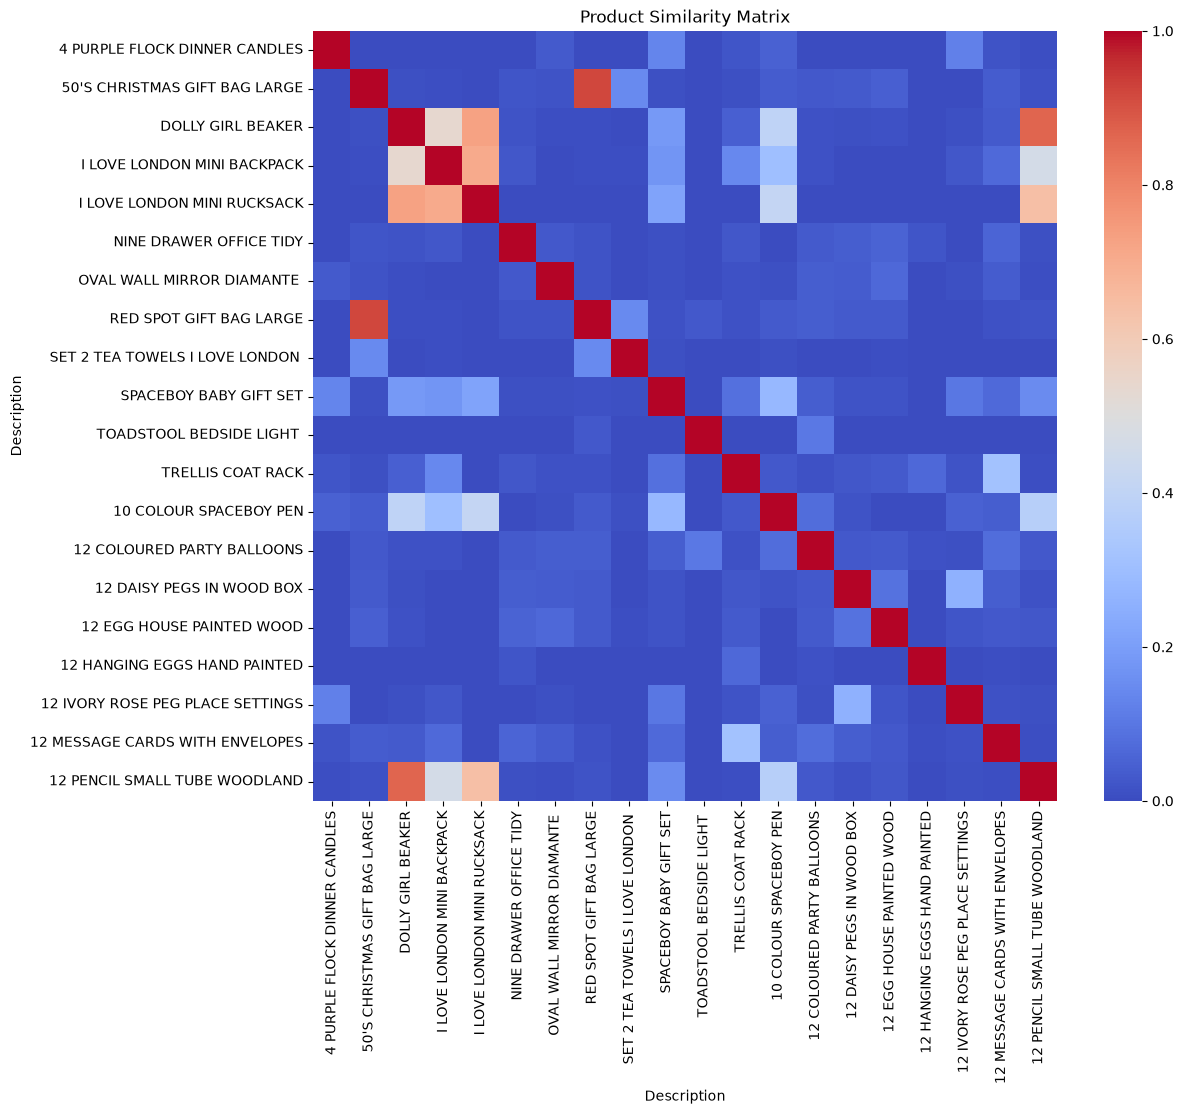

In [22]:
plt.figure(figsize=(12,10))

sns.heatmap(
    similarity_df.iloc[:20,:20],
    cmap='coolwarm'
)

plt.title("Product Similarity Matrix")

plt.show()

In [23]:
pickle.dump(
    similarity_df,
    open("../models/similarity.pkl",'wb')
)

In [24]:
def recommend(product, n=5):

    product = product.upper()

    if product not in similarity_df.index:
        return "Product not found"

    recommendations = (
        similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return pd.DataFrame({
        'Recommended Product': recommendations.index,
        'Similarity Score': recommendations.values
    })

In [25]:
recommend("JUMBO BAG RED RETROSPOT")

,Recommended Product,Similarity Score
0,JUMBO BAG PINK POLKADOT,0.497593
1,JUMBO BAG APPLES,0.465749
2,JUMBO BAG STRAWBERRY,0.458148
3,JUMBO BAG BAROQUE BLACK WHITE,0.452718
4,JUMBO BAG PINK VINTAGE PAISLEY,0.448809
